# Forecasting Traffic

In this lab session, we will apply T-GNNs to a particular case of traffic forecasting. First, we will explore and process a new dataset to create a temporal graph from raw CSV files. We will then apply   A3T-GCN, a new type of T-GNN to predict future traffic speed. Finally, we will visualize and compare the results to a baseline solution to verify that our architecture is relevant.

In [1]:
import torch
#!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html
#!pip install -q torch-geometric-temporal==0.54.0

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Exploring the PeMS-M dataset


The dataset we will use for this application is the medium variant of the PeMSD7 dataset [1]. The original dataset was obtained by collecting traffic speed from 39,000 sensor stations on the weekdays of May and June 2012 using the Caltrans Performance Measurement System (PeMS). We will only consider 228 stations across District 7 of California in the medium variant. These stations output 30-second speed measurements that are aggregated into 5-minute intervals in this dataset. For example, the following figure shows the Caltrans PeMS (pems.dot.ca.gov) with various traffic speeds:




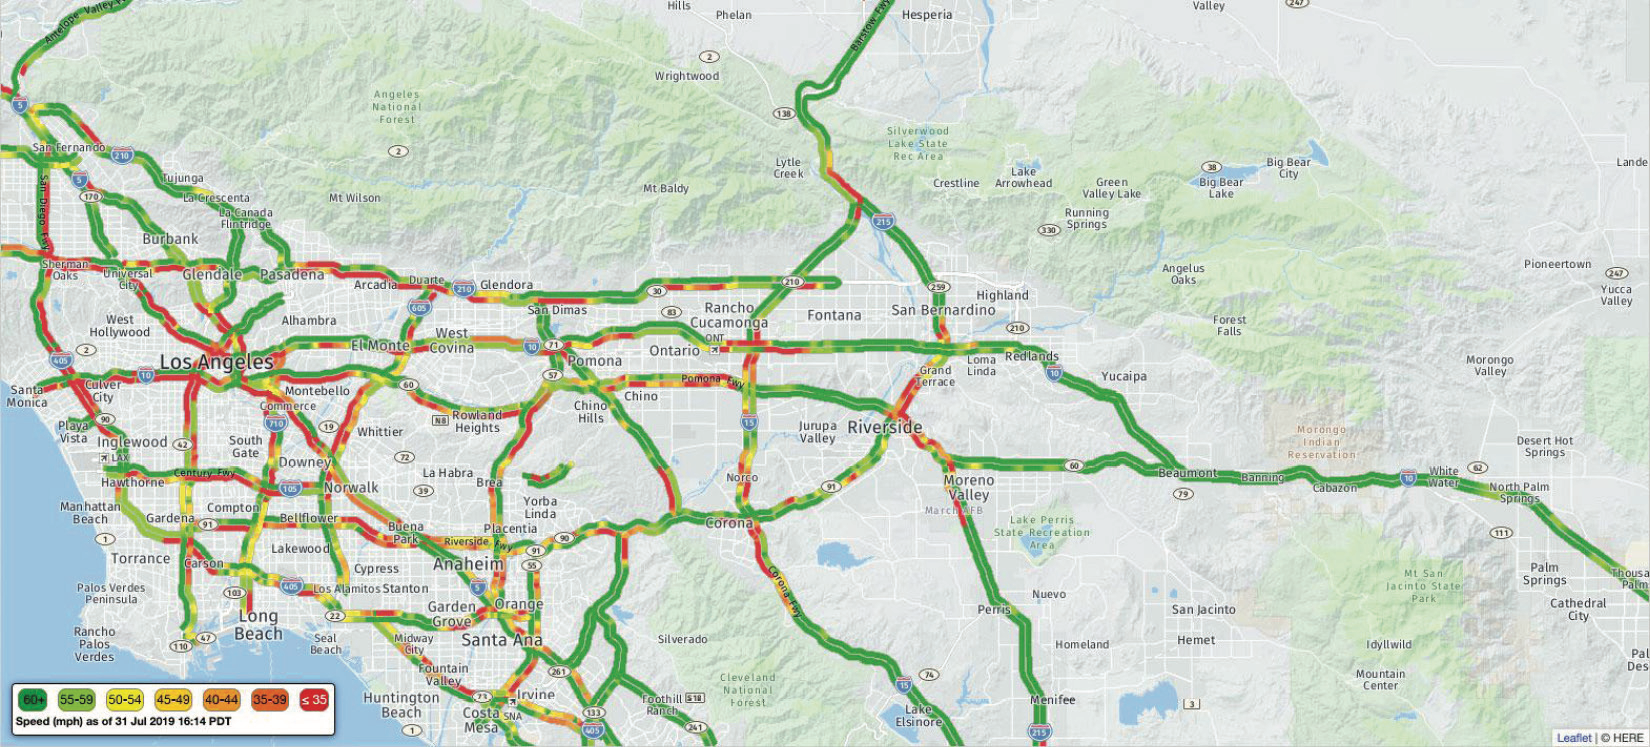


[1] Yu, B., Yin, H., & Zhu, Z. (2017). Spatio-temporal graph convolutional networks: A deep learning framework for traffic forecasting. arXiv preprint arXiv:1709.04875.

We can directly load the dataset from GitHub and unzip it:

In [2]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile


url = 'https://github.com/VeritasYin/STGCN_IJCAI-18/raw/master/dataset/PeMSD7_Full.zip'
#url = 'https://github.com/VeritasYin/STGCN_IJCAI-18/raw/master/data_loader/PeMSD7_Full.zip' # this link is broken (use one above)
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall('.')

The resulting folder contains two files: `V_228.csv` and `W_228.csv`. The `V_228`.csv file contains the traffic speed collected by the 228 sensor stations, and `W_228.csv` stores the distances between these stations.

Let’s load them using pandas. We will rename the columns using range() for easy access:

In [3]:
import pandas as pd

speeds = pd.read_csv('PeMSD7_V_228.csv', names=range(0,228))
distances = pd.read_csv('PeMSD7_W_228.csv', names=range(0,228))

The first thing we want to do with this dataset is to visualize the evolution of traffic speed.  This is a must-do in time series forecasting since characteristics such as seasonality can be extremely helpful. On the other hand, non-stationary time series might need further processing before they can be used.

Let’s plot the traffic speed over time using matplotlib:

Text(0, 0.5, 'Traffic speed')

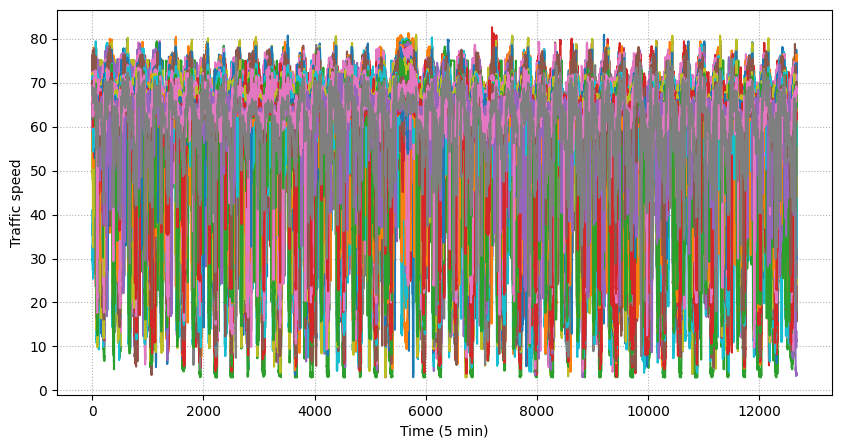

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5), dpi=100) 
plt.plot(speeds) 
plt.grid(linestyle=':') 
plt.xlabel('Time (5 min)') 
plt.ylabel('Traffic speed')  

Unfortunately, the data is too noisy to give us any insight using this approach. Instead, we could plot the data corresponding to a few sensor stations. However, it might not be representative of the entire dataset. There is another option: we can plot the mean traffic speed with standard deviation. That way, we can visualize a summary of the dataset.

In practice, we would use both approaches, but let’s try the second option now:

Text(0, 0.5, 'Traffic speed')

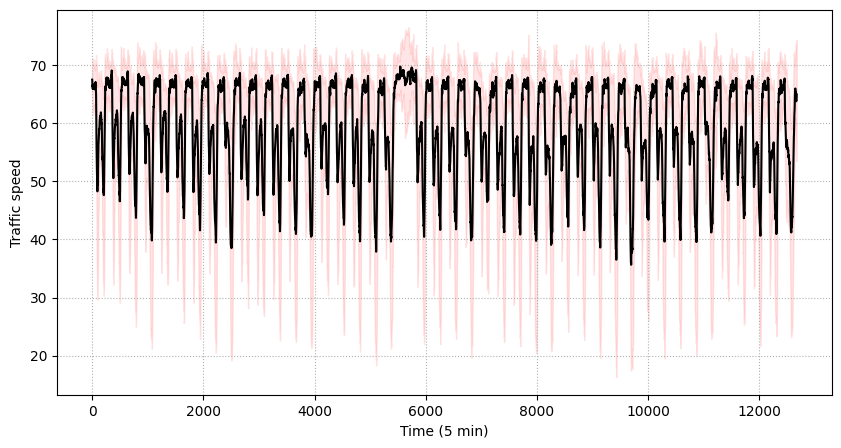

In [5]:
# Plot mean/std traffic speed

# We calculate the mean traffic speed with the corresponding standard deviation for each column (time step):
mean = speeds.mean(axis=1)
std = speeds.std(axis=1)

plt.figure(figsize=(10,5), dpi=100)
# We plot the mean values in black with a solid line:
plt.plot(mean, 'k-')
plt.grid(linestyle=':')
# We plot the standard deviation around the mean values using plt.fill_between() in light red:
plt.fill_between(mean.index, mean-std, mean+std, color='r', alpha=0.1)
plt.xlabel('Time (5 min)')
plt.ylabel('Traffic speed')

This figure is much more comprehensible. We can see a clear seasonality (pattern) in the time series data, except around the $5,800^{th}$ data sample. The traffic speed has a lot of variability with important spikes. This is understandable because the sensor stations are spread throughout District 7 of California: traffic might be jammed for some sensors but not for others.


We can verify that by plotting the correlation between the speed values from every sensor. In addition to that, we can compare it with the distances between each station. Stations close to each other should display similar values more often than distant ones.


Let’s compare these two plots on the same figure:

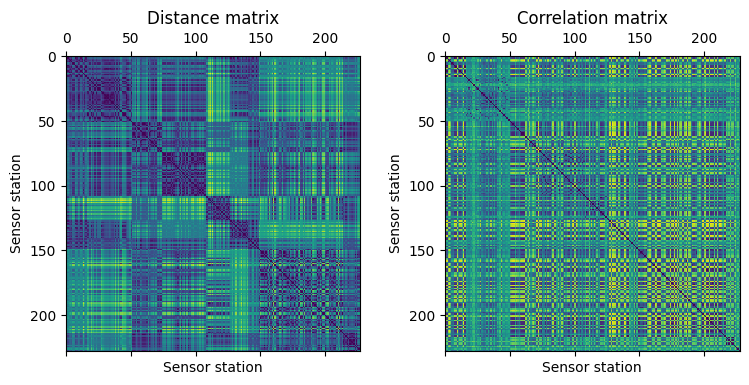

In [6]:
# We can also visualize the correlation between the timeseries in different routes

# We create a figure with two horizontal subplots and some padding between them:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))
fig.tight_layout(pad=3.0)

# First, we use the matshow() function to plot the distance matrix:
ax1.matshow(distances)
ax1.set_xlabel("Sensor station")
ax1.set_ylabel("Sensor station")
ax1.title.set_text("Distance matrix")

# Then, we calculate the Pearson correlation coefficients for each sensor station.
# We must transpose the speed matrix or we will get the correlation coefficients for each time step instead. 
# Finally, we invert them, so the two plots are easier to compare:
ax2.matshow(-np.corrcoef(speeds.T))
ax2.set_xlabel("Sensor station")
ax2.set_ylabel("Sensor station")
ax2.title.set_text("Correlation matrix")

Interestingly, long distances between stations do not mean they are not highly correlated (and vice versa). This is particularly important if we only consider a subset of this dataset: close stations might have very different outputs, making traffic forecasting more difficult. Here, we will take into account every sensor station in the dataset.

## Processing the dataset

Now that we have more information about this dataset, it is time to process it before we can feed it to a T-GNN.


The first step consists of transforming the tabular dataset into a temporal graph. So, first, we need to create a graph from the raw data. In other words, we must connect the different sensor stations in a meaningful way. Fortunately, we have access to the distance matrix, which should be a good way to connect the stations.


There are several options to compute the adjacency matrix from the distance matrix. For example, we could assign a link when the distance between two stations is inferior to the mean distance. Instead, we will perform a more advanced processing introduced in [2] to calculate a weighted adjacency matrix. Instead of binary values, we calculate weights between 0 (no connection) and 1 (strong connection) using the following formula:

$$w_{i,j}= exp(-\frac{d^2_{i,j}}{\sigma^2}), ~if~i\neq j~and~exp(-\frac{d^2_{i,j}}{\sigma^2})\geq \epsilon$$
$$w_{i,j}= 0 ~otherwise $$


Here, $W_{i,j}$ represents the weight of the edge from node i to node j, $d_{i,j}$ is the distance between these two nodes.  $\sigma^2$ and $\epsilon$  are two thresholds to control the distribution and sparsity of the adjacency matrix. The official implementation of [2] is available on GitHub (https://github.com/VeritasYin/STGCN_IJCAI-18). We will reuse the same threshold values $\sigma^2 = 0.1$ and $\epsilon = 0.5$.

[2] Li, Y., Yu, R., Shahabi, C., & Liu, Y. (2017). Diffusion convolutional recurrent neural network: Data-driven traffic forecasting. arXiv preprint arXiv:1707.01926.

Let’s implement it  and plot the resulting adjacency matrix.


We create a function to compute the adjacency matrix that takes three parameters: the distance matrix and the two thresholds $\sigma^2$ and $\epsilon$. Like in the official implementation, we divide the distances by 10,000 and calculate $d^2$.


Here, we want weights when their values are greater than or equal to $\epsilon$ (otherwise, they should be equal to zero). When we test whether the weights are greater than or equal to $\epsilon$, the results are `True` or `False` statements. This is why we need a mask of ones (`w_mask`) to convert it back into 0 and 1 values. We multiply it a second time so that we only obtain the real values of weights that are greater than or equal to $\epsilon$:

In [7]:
def compute_adj(distances, sigma2=0.1, epsilon=0.5):
    d = distances.to_numpy() / 10000.
    d2 = d * d
    n = distances.shape[0]  
    w_mask = np.ones([n, n]) - np.identity(n)
    return np.exp(-d2 / sigma2) * (np.exp(-d2 / sigma2) >= epsilon) * w_mask



# Let’s compute our adjacency matrix
adj = compute_adj(distances)



We visualize this matrix using  matplotlib’s `matshow`:

Text(0, 0.5, 'Sensor station')

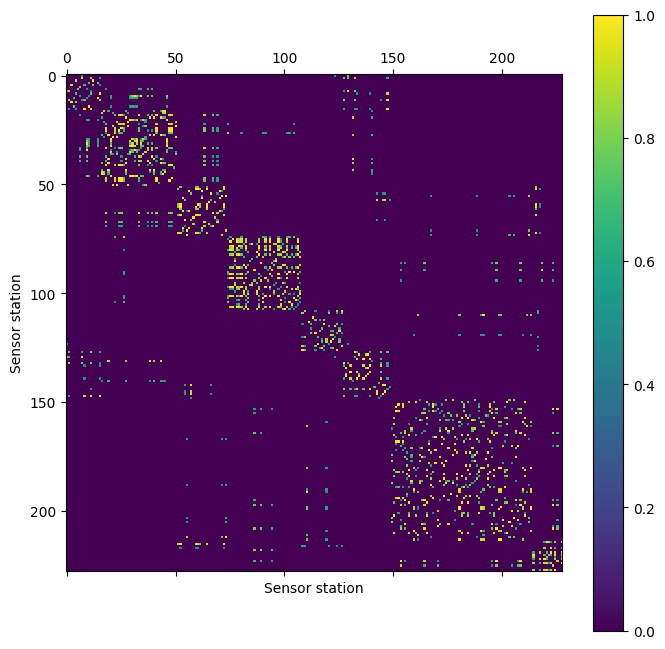

In [8]:
plt.figure(figsize=(8, 8))
cax = plt.matshow(adj, False)
plt.colorbar(cax)
plt.xlabel("Sensor station")
plt.ylabel("Sensor station")

## TODO

This is a great way to summarize this first processing step. We can compare it to the distance matrix we previously plotted to find similarities.
**Do it!**

In [ ]:
def compute_and_plot(distances, sigma2=0.1, epsilon=0.5):
    adj = compute_adj(distances,sigma2,epsilon)
    plt.figure(figsize=(8, 8))
    cax = plt.matshow(adj, False)
    plt.colorbar(cax)
    plt.xlabel("Sensor station")
    plt.ylabel("Sensor station")
    return adj
#compute_and_plot()

TypeError: compute_and_plot() missing 1 required positional argument: 'distances'

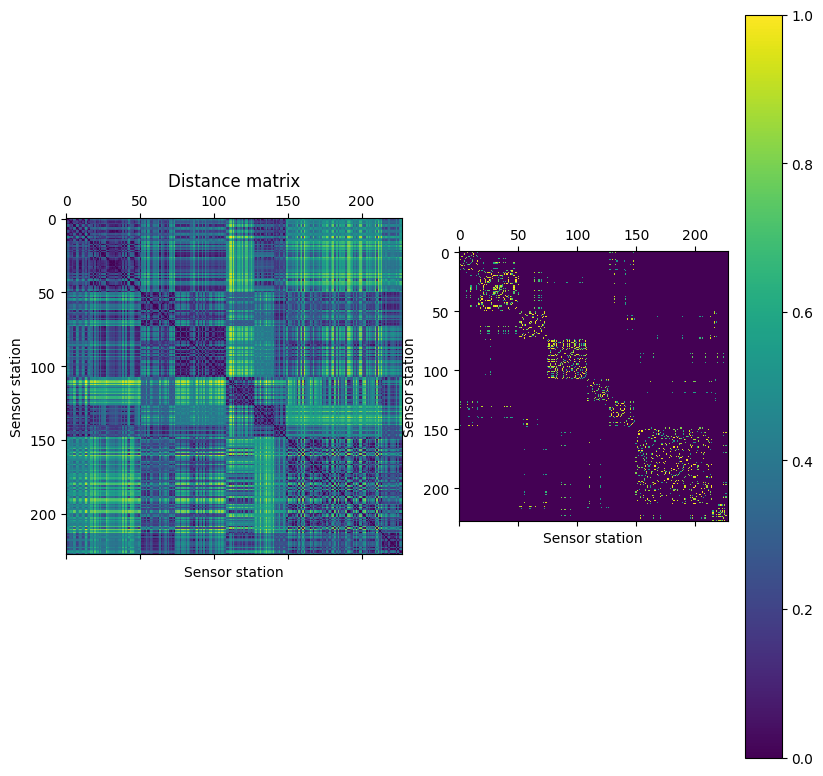

In [ ]:
#TODO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))
fig.tight_layout(pad=1.0)


# First, we use the matshow() function to plot the distance matrix:
ax1.matshow(distances)
ax1.set_xlabel("Sensor station")
ax1.set_ylabel("Sensor station")
ax1.title.set_text("Distance matrix")

cax = ax2.matshow(adj)
ax2.set_xlabel("Sensor station")
ax2.set_ylabel("Sensor station")
fig.colorbar(cax)


We can also directly plot it as a graph using networkx. In this case, connections are binary, so we can simply consider every weight higher than 0. We could display these values using edge labels, but the graph would be extremely difficult to read:

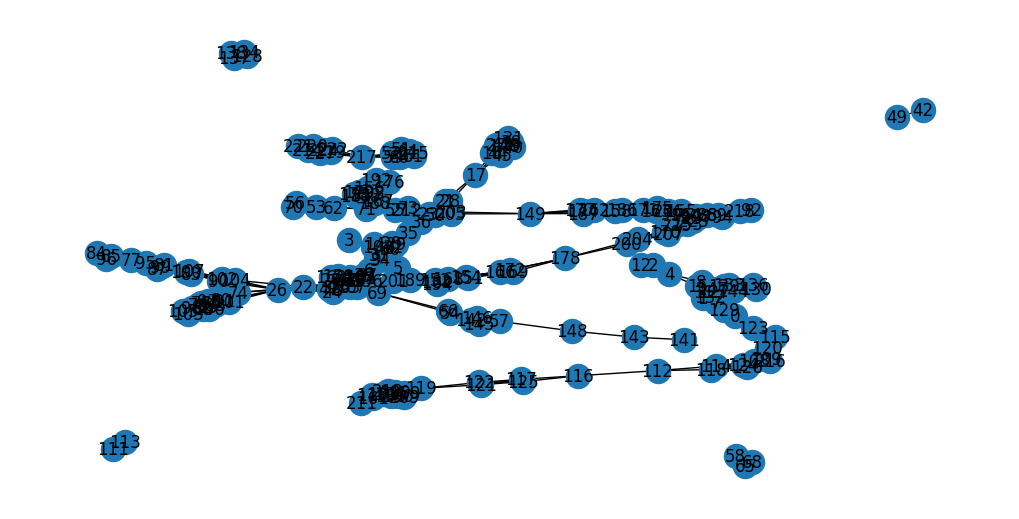

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_graph(adj):
    plt.figure(figsize=(10,5))
    rows, cols = np.where(adj > 0)
    edges = zip(rows.tolist(), cols.tolist())
    G = nx.Graph()
    G.add_edges_from(edges)
    nx.draw(G, with_labels=True)
    plt.show()

plot_graph(adj)

Many nodes are interconnected because they are very close to each other. Yet, despite that, we can distinguish several branches that could correspond to actual roads.

Now that we have a graph, we can focus on the time series aspect of this problem. The first step consists of normalizing the speed values so they can be fed to a neural network. In the traffic forecasting literature, many authors choose a z-score normalization (or standardization), which we will implement here:

In [ ]:
# Apply z-score
def zscore(x, mean, std):
    return (x - mean) / std

speeds_norm = zscore(speeds, speeds.mean(axis=0), speeds.std(axis=0))

speeds_norm.head(1)



,0,1,2,3,4,5,6,7,8,9,...,218,219,220,221,222,223,224,225,226,227
0,0.950754,0.548255,0.502211,0.831672,0.793696,1.193806,0.983384,0.737268,0.933144,-0.718118,...,0.542628,1.011204,0.609678,0.79198,0.709507,0.734163,0.569479,1.04614,0.712316,1.046962


These values are correctly standardized. Now, we can use them to create time series for each node. We want n input data samples at each time step t, to predict the speed value at t+h. A high number of input data samples also increases the memory footprint of the dataset. The value for h, also called the horizon, depends on the task we want to perform: short-term or long-term traffic forecasting.


In this example, let’s take a high value of 48 to predict the traffic speed in 4 hours:

In [ ]:
# Create dataset

# We initialize the variables: the number of lags (number of input data samples), horizon, the input matrix, and the ground-truth matrix:
lags = 24
horizon = 48
xs = []
ys = []

# For each time step t, we store the 12 (lags) previous values in xs and the value at t+h in ys:
for i in range(lags, speeds_norm.shape[0]-horizon):
    xs.append(speeds_norm.to_numpy()[i-lags:i].T)
    ys.append(speeds_norm.to_numpy()[i+horizon-1])



## Convert adjacency matrix to edge_index (COO format)

Finally, we can create the temporal graph using PyTorch Geometric Temporal. We need to give the edge index in COO format and the edge weight from the weighted adjacency matrix:

In [ ]:
%pip install torch_geometric_temporal
from torch_geometric_temporal.signal import StaticGraphTemporalSignal
edge_index = (np.array(adj) > 0).nonzero()
edge_weight = adj[adj > 0]
dataset = StaticGraphTemporalSignal(edge_index, adj[adj > 0], xs, ys)

# Let’s print information about the first graph to see whether everything looks good:
dataset[0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 13.3 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: decorator
    Found existing installation: decorator 5.2.1
    Uninstalling decorator-5.2.1:
      Successfully uninstalled decorator-5.2.1━━ 0/3 [decorator]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torch_geometric_temporal]eometric_temporal]
Note: you may need to restart the kernel to use updated packages.


/home/pierre/Desktop/epita/maj/ing3/gnn/.venv/lib/python3.12/site-packages/torch_geometric_temporal/signal/static_graph_temporal_signal.py:66: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.LongTensor(self.edge_index)


Data(x=[228, 24], edge_index=[2, 1664], edge_attr=[1664], y=[228])

Let’s not forget the train/test split to finalize our dataset:

In [ ]:
from torch_geometric_temporal.signal import temporal_signal_split

train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)



The final temporal graph has 228 nodes with 12 values and 1,664 connections. We are now ready to apply a T-GNN to predict traffic.

## Implementing the A3T-GCN architecture

we will train an Attention Temporal Graph Convolutional Network (A3T-GCN), designed for traffic forecasting. This architecture allows us to consider complex spatial and temporal dependencies:

* Spatial dependencies refer to the fact that the traffic condition of a location can be influenced by the traffic condition of nearby locations. For example, traffic jams often spread to neighboring roads.

* Temporal dependencies refer to the fact that the traffic condition of a location at a time can be influenced by the traffic condition of the same location at previous times. For example, if a road is congested during the morning peak, it is likely to remain congested until the evening peak.


A3T-GCN is an improvement over the temporal GCN (TGCN) architecture. The TGCN is a combination of a GCN and GRU that produces hidden vectors from each input time series. The combination of these two layers captures spatial and temporal information from the input. An attention model is then used to calculate weights and output a context vector. The final prediction is based on the resulting context vector. The addition of this attention model is motivated by the need to understand global trends.



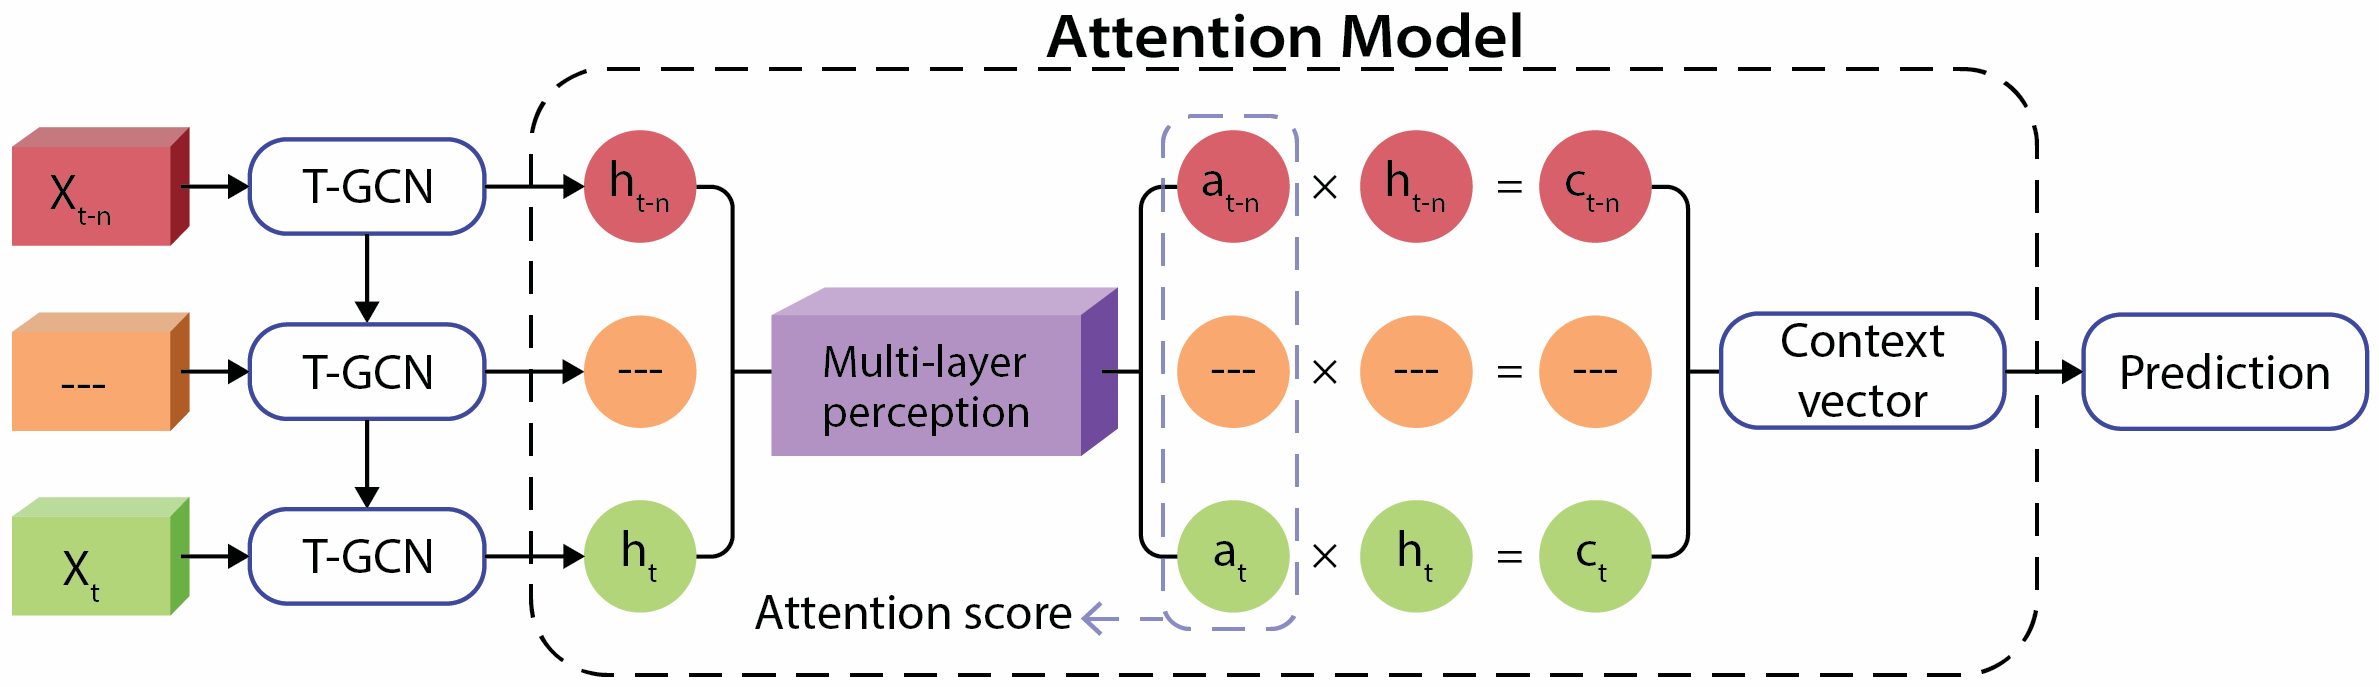


We will now implement it using the PyTorch Geometric Temporal library.


In [ ]:
import torch
from torch_geometric_temporal.nn.recurrent import A3TGCN

# We create a T-GNN with an A3TGCN layer and a linear layer with 32 hidden dimensions. The edge_attr parameter will store our edge weights:
class TemporalGNN(torch.nn.Module):
    def __init__(self, dim_in, periods):
        super().__init__()
        self.tgnn = A3TGCN(in_channels=dim_in, out_channels=32, periods=periods)
        self.linear = torch.nn.Linear(32, periods)

    def forward(self, x, edge_index, edge_attr):
        h = self.tgnn(x, edge_index, edge_attr).relu()
        h = self.linear(h)
        return h


# We instantiate the T-GNN and the Adam optimizer with a learning rate of 0.005. 
# Due to implementation details, we will train this model using a CPU instead of a GPU, which is faster in this case (but you can try)

model = TemporalGNN(lags, 1).to('cpu')
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
model.train()
print(model)

# Training

# We train the model for 30 epochs using the Mean Squared Error (MSE) as the loss function.
# The loss value is backpropagated after each epoch:

for epoch in range(30):
    loss = 0
    step = 0
    for i, snapshot in enumerate(train_dataset):
        y_pred = model(snapshot.x.unsqueeze(2), snapshot.edge_index, snapshot.edge_attr)
        loss += torch.mean((y_pred-snapshot.y)**2)
        step += 1
    loss = loss / (step + 1)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if epoch % 5 == 0:
        print(f"Epoch {epoch:>2} | Train MSE: {loss:.4f}")

TemporalGNN(
  (tgnn): A3TGCN(
    (_base_tgcn): TGCN(
      (conv_z): GCNConv(24, 32)
      (linear_z): Linear(in_features=64, out_features=32, bias=True)
      (conv_r): GCNConv(24, 32)
      (linear_r): Linear(in_features=64, out_features=32, bias=True)
      (conv_h): GCNConv(24, 32)
      (linear_h): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


Now that our model is trained, we have to evaluate it. Beyond classic metrics such as Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE), it is particularly helpful to compare our model to a baseline solution with time series data. In the following list, we will introduce two methods:

* Using Random Walk (RW) as a naive forecaster. In this case, RW refers to using the last observation as the predicted value. In other words, the value at t is the same one as at t+h.

* Using Historical Average (HA) as a slightly more evolved solution. In this case, we calculate the mean traffic speed of k previous samples as the value at t+h. In this example, we will use the number of lags as our k 
value, but we could also take the overall historical average.


Let’s start by evaluating the model’s predictions on the test set:

In [ ]:
# We create a function to invert the z-score and get back to the original values:
def inverse_zscore(x, mean, std):
    return x * std + mean

# We use it to recalculate the speeds we want to predict from their normalized values. The following loop is not very efficient, but it is clearer to understand than more optimized code:
y_test = []
for snapshot in test_dataset:
    y_hat = snapshot.y.numpy()
    y_hat = inverse_zscore(y_hat, speeds.mean(axis=0), speeds.std(axis=0))
    y_test = np.append(y_test, y_hat)

# We apply the same strategy to the predictions made by the GNN:
gnn_pred = []
model.eval()
for snapshot in test_dataset:
    snapshot = snapshot
    y_hat = model(snapshot.x.unsqueeze(2), snapshot.edge_index, snapshot.edge_weight).squeeze().detach().numpy()
    y_hat = inverse_zscore(y_hat, speeds.mean(axis=0), speeds.std(axis=0))
    gnn_pred = np.append(gnn_pred, y_hat)

We create functions to calculate the MAE, RMSE, and the Mean Absolute Percentage Error (MAPE):

In [ ]:
def MAE(real, pred):
    return np.mean(np.abs(pred - real))

def RMSE(real, pred):
    return np.sqrt(np.mean((pred - real) ** 2))

def MAPE(real, pred):
    return np.mean(np.abs(pred - real) / (real + 1e-5))

# We evaluate the GNN’s predictions in the following block and repeat this process for every technique:

print(f'GNN MAE  = {MAE(gnn_pred, y_test):.4f}')
print(f'GNN RMSE = {RMSE(gnn_pred, y_test):.4f}')
print(f'GNN MAPE = {MAPE(gnn_pred, y_test):.4f}')

GNN MAE  = 8.3602
GNN RMSE = 12.1247
GNN MAPE = 0.1485


We do the same thing for the RW and HA techniques:

In [ ]:
rw_pred = []
for snapshot in test_dataset:
    y_hat = snapshot.x[:,-1].squeeze().detach().numpy()
    y_hat = inverse_zscore(y_hat, speeds.mean(axis=0), speeds.std(axis=0))
    rw_pred = np.append(rw_pred, y_hat)

print(f'RW MAE  = {MAE(rw_pred, y_test):.4f}')
print(f'RW RMSE = {RMSE(rw_pred, y_test):.4f}')
print(f'RW MAPE = {MAPE(rw_pred, y_test):.4f}')

RW MAE  = 11.0469
RW RMSE = 17.6501
RW MAPE = 0.2999


In [ ]:
ha_pred = []
for i in range(lags, speeds_norm.shape[0]-horizon):
    y_hat = speeds_norm.to_numpy()[:i].T.mean(axis=1)
    y_hat = inverse_zscore(y_hat, speeds.mean(axis=0), speeds.std(axis=0)) 
    ha_pred.append(y_hat)
ha_pred = np.array(ha_pred).flatten()[-len(y_test):]

print(f'HA MAE  = {MAE(ha_pred, y_test):.4f}')
print(f'HA RMSE = {RMSE(ha_pred, y_test):.4f}')
print(f'HA MAPE = {MAPE(ha_pred, y_test):.4f}')

HA MAE  = 9.3374
HA RMSE = 13.1518
HA MAPE = 0.1633


We see that the baseline techniques are outperformed by the A3T-GCN model in every metric. This is an important result because baselines can often be difficult to beat. It would be interesting to compare these metrics to the predictions provided by LSTM or GRU networks to measure the importance of the topological information (**TODO**)

Finally, we can plot the mean predictions to obtain a visualization

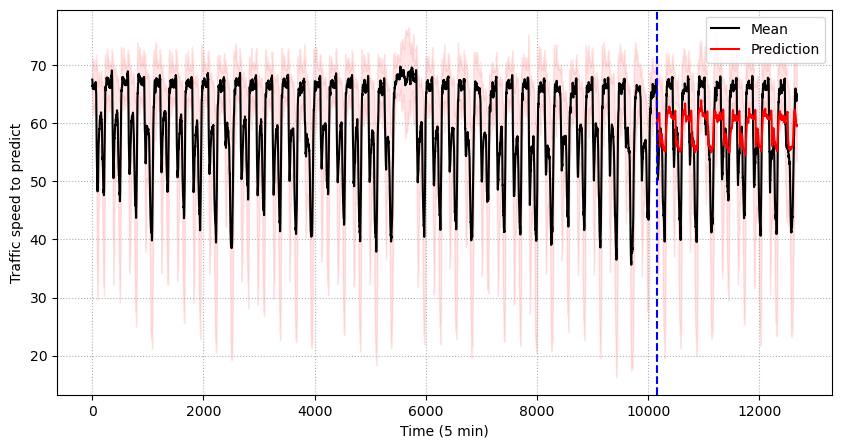

In [ ]:
y_preds = [inverse_zscore(model(snapshot.x.unsqueeze(2), snapshot.edge_index, snapshot.edge_weight).squeeze().detach().numpy(), speeds.mean(axis=0), speeds.std(axis=0)).mean() for snapshot in test_dataset]

mean = speeds.mean(axis=1)
std = speeds.std(axis=1)

plt.figure(figsize=(10,5))
plt.plot(np.array(mean), 'k-', label='Mean')
plt.plot(range(len(speeds)-len(y_preds), len(speeds)), y_preds, 'r-', label='Prediction')
plt.grid(linestyle=':')
plt.fill_between(mean.index, mean-std, mean+std, color='r', alpha=0.1)
plt.axvline(x=len(speeds)-len(y_preds), color='b', linestyle='--')
plt.xlabel('Time (5 min)')
plt.ylabel('Traffic speed to predict')
plt.legend(loc='upper right')

The T-GNN correctly predicts spikes and follows the general trend. However, the predicted speeds are closer to the overall average value, as it is more costly for the model to make serious mistakes due to the MSE loss. Despite that, the GNN is quite accurate and could be fine-tuned to output more extreme values.

## TODO

Are we sure that A3T-GNN is better than  T-GNN architectures ? 
* Implement EvolveGCN-O and EvolveGCN-H architectures to compare with.

Similarly, are we sure that the graph structure improves the accuracy of the prediction ? 
* compare with models learned on tabular data ? (or sequential data if you have time)

In [ ]:
#TODO